# Laboratorio 3 — Predicción de Series Temporales con MLP y Redes Recurrentes

**Objetivo:** Predecir cotizaciones diarias EUR/USD usando distintas arquitecturas de redes neuronales y comparar sus resultados.

---

## Índice
1. Configuración inicial
2. Dataset EUR/USD (≥5 años)
3. Preprocesamiento
4. Baseline Naive
5. **MLP real** (capas ocultas + activaciones)
6. **LSTM** (con gradient clipping)
7. **Modelo pre-entrenado** (fine-tuning corregido)
8. Comparativa MLP vs LSTM
9. **BiLSTM** sobre consumo energético (dataset diferente, fuera de NLP)
10. Conclusión

---

## Teoría: ¿por qué estas arquitecturas?

### MLP (Perceptrón Multicapa)
Un MLP aplana la ventana temporal y aprende relaciones entre los `t` valores de entrada. **Limitación:** trata cada posición de la ventana de forma independiente; no entiende que `t-1` está antes que `t-2`. Es un buen punto de partida para medir si la estructura temporal agrega valor real.

![MLP](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

### LSTM (Long Short-Term Memory)
Procesa la secuencia **paso a paso**, manteniendo un estado oculto que actúa como memoria. Las puertas de olvido, entrada y salida controlan qué información se retiene a lo largo del tiempo. Esto le permite capturar dependencias de largo plazo en la serie.

### BiLSTM (LSTM Bidireccional)
Combina dos LSTMs: uno procesa la secuencia de **izquierda a derecha** y otro de **derecha a izquierda**. Al analizar datos históricos completos (no en tiempo real), el contexto futuro dentro de la ventana ayuda a identificar patrones cíclicos con mayor precisión.

---
## 1. Configuración inicial
Fijamos semillas para reproducibilidad y detectamos si hay GPU disponible.

In [1]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from pathlib import Path

# ── Semillas para reproducibilidad ──────────────────────────────────────────
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.cuda.manual_seed(SEMILLA)

# ── Dispositivo (GPU si está disponible) ────────────────────────────────────
dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de cómputo: {dispositivo}')
if dispositivo == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo de cómputo: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


---
## 2. Dataset EUR/USD — Cotización diaria (2015–2024)

Usamos el tipo de cambio Euro/Dólar de la Reserva Federal de EE.UU. (FRED).
El archivo `DEXUSEU.csv` debe estar en el mismo directorio, o se descarga automáticamente con `pandas_datareader`.

**¿Por qué ≥5 años?** El dataset debe cubrir múltiples temporadas, ciclos económicos y eventos (COVID-2020, crisis energética 2022) para que el modelo generalice bien.

In [ ]:
from pathlib import Path
import pandas_datareader.data as web
from datetime import datetime

# ── Intentar cargar localmente; si no existe, descargar de FRED ──────────────
archivo_local = Path('DEXUSEU.csv')

if archivo_local.exists():
    datos_fx = pd.read_csv(archivo_local)
    col_fecha = 'observation_date' if 'observation_date' in datos_fx.columns else 'DATE'
    col_valor = 'DEXUSEU'         if 'DEXUSEU'           in datos_fx.columns else 'close'
    datos_fx = (
        datos_fx[[col_fecha, col_valor]]
        .rename(columns={col_fecha: 'DATE', col_valor: 'close'})
    )
    print('Dataset cargado desde archivo local.')
else:
    print('Descargando EUR/USD desde FRED (2015-2024)...')
    datos_fx = web.DataReader(
        'DEXUSEU', 'fred',
        start=datetime(2015, 1, 1),
        end=datetime(2024, 12, 31)
    ).reset_index()
    datos_fx.columns = ['DATE', 'close']
    datos_fx.to_csv(archivo_local, index=False)
    print('Dataset descargado y guardado.')

# ── Limpieza básica ──────────────────────────────────────────────────────────
datos_fx['DATE']  = pd.to_datetime(datos_fx['DATE'])
datos_fx['close'] = pd.to_numeric(datos_fx['close'], errors='coerce')
datos_fx = datos_fx.dropna().reset_index(drop=True)

print(f'Registros totales : {len(datos_fx):,}')
print(f'Período           : {datos_fx["DATE"].min().date()} → {datos_fx["DATE"].max().date()}')
print(f'\nEstadísticas:\n{datos_fx["close"].describe().round(4)}')

Dataset cargado desde archivo local.
Registros totales : 2,046
Período           : 2018-01-02 → 2026-03-13

Estadísticas:
count    2046.0000
mean        1.1228
std         0.0562
min         0.9616
25%         1.0840
50%         1.1210
75%         1.1676
max         1.2488
Name: close, dtype: float64


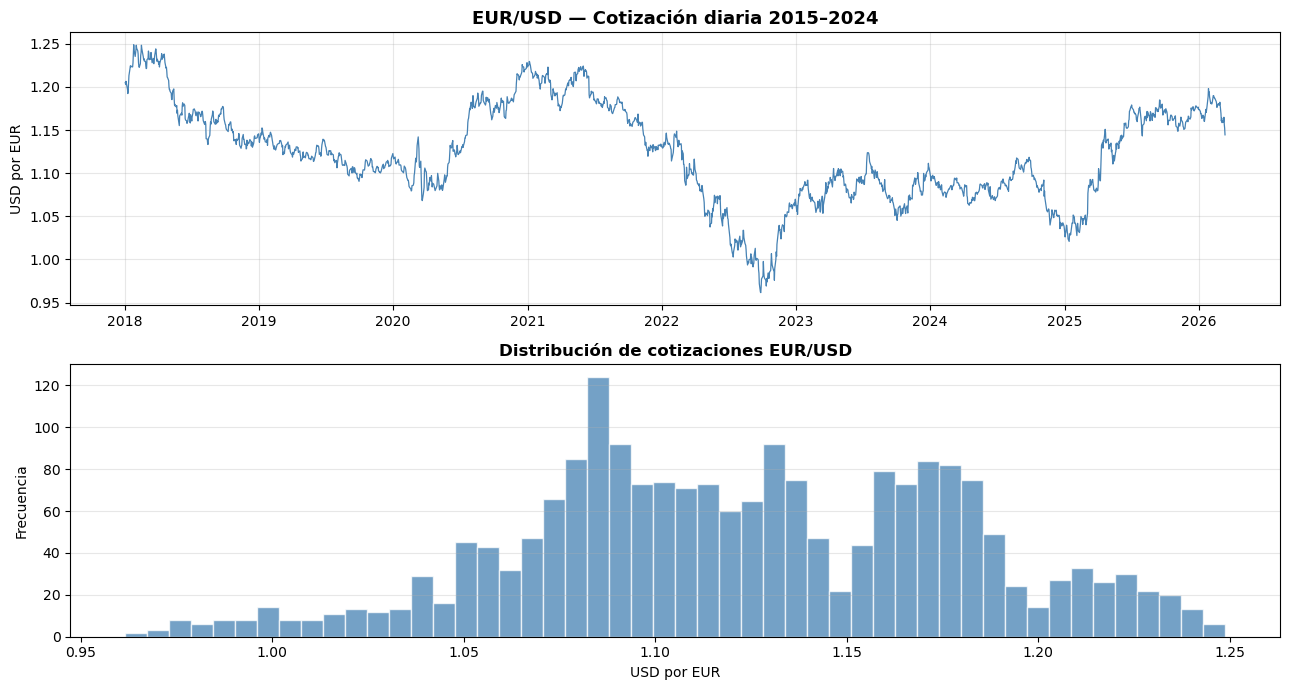

In [3]:
# ── Visualización de la serie completa ──────────────────────────────────────
fig, ejes = plt.subplots(2, 1, figsize=(13, 7))

# Serie temporal completa
ejes[0].plot(datos_fx['DATE'], datos_fx['close'],
             color='steelblue', linewidth=0.9)
ejes[0].set_title('EUR/USD — Cotización diaria 2015–2024',
                  fontsize=13, fontweight='bold')
ejes[0].set_ylabel('USD por EUR')
ejes[0].grid(alpha=0.3)

# Histograma de la distribución de valores
ejes[1].hist(datos_fx['close'], bins=50, color='steelblue',
             alpha=0.75, edgecolor='white')
ejes[1].set_title('Distribución de cotizaciones EUR/USD',
                  fontsize=12, fontweight='bold')
ejes[1].set_xlabel('USD por EUR')
ejes[1].set_ylabel('Frecuencia')
ejes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento

Pasos:
1. **Normalización MinMax [0,1]** — para estabilizar el entrenamiento.
2. **Ventana deslizante** — cada muestra es una secuencia de `pasos_ventana` días; el target es el día siguiente.
3. **División temporal 70/15/15** — **sin mezclar** (los datos del futuro no pueden aparecer en entrenamiento).

> ⚠️ El escalador se ajusta **solo sobre el conjunto de entrenamiento** y luego se aplica a validación y test para evitar *data leakage*.

In [4]:
# ── Normalización (ajuste solo en train para evitar data leakage) ────────────
serie_bruta = datos_fx['close'].values

PASOS_VENTANA = 50   # 50 días de contexto para predecir el día 51

# Creamos el escalador ANTES de dividir el dataset, pero lo ajustamos
# después, solo sobre los datos de entrenamiento (ver más abajo).
escalador_fx = MinMaxScaler(feature_range=(0, 1))

# ── Función: ventana deslizante ──────────────────────────────────────────────
def crear_ventanas(serie: np.ndarray, pasos: int):
    """
    Transforma una serie 1-D en pares (X, y) con ventana deslizante.
    X[i] = serie[i : i+pasos]   (los 'pasos' valores anteriores)
    y[i] = serie[i+pasos]       (el valor a predecir)
    """
    x_lista, y_lista = [], []
    for i in range(len(serie) - pasos):
        x_lista.append(serie[i : i + pasos])
        y_lista.append(serie[i + pasos])
    return np.array(x_lista), np.array(y_lista)

# ── División temporal de la serie ANTES de normalizar ───────────────────────
n_total = len(serie_bruta)
corte_train = int(n_total * 0.70)
corte_val   = int(n_total * 0.85)

serie_train_raw = serie_bruta[:corte_train]
serie_val_raw   = serie_bruta[corte_train:corte_val]
serie_test_raw  = serie_bruta[corte_val:]

# Ajuste del escalador SOLO en train
escalador_fx.fit(serie_train_raw.reshape(-1, 1))

# Aplicar normalización a cada split
def normalizar(serie, escalador):
    return escalador.transform(serie.reshape(-1, 1)).flatten()

serie_train_norm = normalizar(serie_train_raw, escalador_fx)
serie_val_norm   = normalizar(serie_val_raw,   escalador_fx)
serie_test_norm  = normalizar(serie_test_raw,  escalador_fx)

# ── Crear ventanas para cada split ──────────────────────────────────────────
# Para validación y test necesitamos los últimos 'pasos_ventana' días
# del split anterior como contexto inicial.
serie_val_ext  = np.concatenate([serie_train_norm[-PASOS_VENTANA:], serie_val_norm])
serie_test_ext = np.concatenate([serie_val_norm[-PASOS_VENTANA:],   serie_test_norm])

x_entrenamiento, y_entrenamiento = crear_ventanas(serie_train_norm, PASOS_VENTANA)
x_validacion,    y_validacion    = crear_ventanas(serie_val_ext,    PASOS_VENTANA)
x_prueba,        y_prueba        = crear_ventanas(serie_test_ext,   PASOS_VENTANA)

print(f'Ventana de contexto : {PASOS_VENTANA} días')
print(f'Entrenamiento : X={x_entrenamiento.shape}  y={y_entrenamiento.shape}')
print(f'Validación    : X={x_validacion.shape}  y={y_validacion.shape}')
print(f'Prueba        : X={x_prueba.shape}  y={y_prueba.shape}')

Ventana de contexto : 50 días
Entrenamiento : X=(1382, 50)  y=(1382,)
Validación    : X=(307, 50)  y=(307,)
Prueba        : X=(307, 50)  y=(307,)


---
## 3.1 Datasets y DataLoaders de PyTorch

Encapsulamos los arrays en objetos `Dataset` y `DataLoader` para el manejo eficiente de lotes (batches) durante el entrenamiento.

In [5]:
class DatasetSerieTemporal(Dataset):
    """
    Dataset de PyTorch para series temporales con ventana deslizante.
    En modo 'entrenamiento=False' (split de prueba) solo devuelve X
    porque la predicción se hace sin etiquetas en producción.
    """
    def __init__(self, x: np.ndarray, y: np.ndarray = None, entrenamiento: bool = True):
        self.x            = x
        self.y            = y
        self.entrenamiento = entrenamiento

    def __len__(self):
        return len(self.x)

    def __getitem__(self, indice):
        x_tensor = torch.tensor(self.x[indice], dtype=torch.float32)
        if self.entrenamiento and self.y is not None:
            y_tensor = torch.tensor(self.y[indice], dtype=torch.float32)
            return x_tensor, y_tensor
        return x_tensor


# ── Construcción de datasets ─────────────────────────────────────────────────
conjuntos_fx = {
    'entrenamiento' : DatasetSerieTemporal(x_entrenamiento, y_entrenamiento, entrenamiento=True),
    'validacion'    : DatasetSerieTemporal(x_validacion,    y_validacion,    entrenamiento=True),
    'prueba'        : DatasetSerieTemporal(x_prueba,        y_prueba,        entrenamiento=False),
}

# shuffle=True solo en entrenamiento; test y val en orden temporal
BATCH = 64
cargadores_fx = {
    'entrenamiento' : DataLoader(conjuntos_fx['entrenamiento'], batch_size=BATCH, shuffle=True),
    'validacion'    : DataLoader(conjuntos_fx['validacion'],    batch_size=BATCH, shuffle=False),
    'prueba'        : DataLoader(conjuntos_fx['prueba'],        batch_size=BATCH, shuffle=False),
}

print('DataLoaders creados correctamente.')
print(f'  Lotes de entrenamiento : {len(cargadores_fx["entrenamiento"])}')
print(f'  Lotes de validación    : {len(cargadores_fx["validacion"])}')
print(f'  Lotes de prueba        : {len(cargadores_fx["prueba"])}')

DataLoaders creados correctamente.
  Lotes de entrenamiento : 22
  Lotes de validación    : 5
  Lotes de prueba        : 5


---
## 3.2 Funciones reutilizables de entrenamiento y evaluación

Definimos una función genérica `entrenar_modelo` que funciona para cualquier arquitectura (MLP, LSTM, etc.) y una función `predecir_modelo` para el split de test.

In [6]:
def entrenar_modelo(
    modelo: nn.Module,
    cargadores: dict,
    epocas: int = 50,
    lr: float = 1e-3,
    clip_grad: float = 1.0
) -> dict:
    """
    Entrena un modelo de PyTorch con el esquema estándar:
      - Optimizador: Adam
      - Pérdida: MSE
      - Gradient clipping para evitar explosión de gradientes
      - Registro de pérdida de entrenamiento y validación por época

    Retorna un diccionario con el historial de pérdidas para graficar.
    """
    modelo.to(dispositivo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio    = nn.MSELoss()

    historial = {'perdida_entrenamiento': [], 'perdida_validacion': []}
    barra = tqdm(range(1, epocas + 1), desc='Entrenando')

    for epoca in barra:
        # ── Fase de entrenamiento ────────────────────────────────────────────
        modelo.train()
        perdidas_train = []
        for lote in cargadores['entrenamiento']:
            x_lote, y_lote = lote
            x_lote = x_lote.to(dispositivo)
            y_lote = y_lote.to(dispositivo)

            optimizador.zero_grad()
            prediccion = modelo(x_lote).squeeze()
            perdida    = criterio(prediccion, y_lote)
            perdida.backward()

            # Gradient clipping: evita que los gradientes crezcan sin control
            nn.utils.clip_grad_norm_(modelo.parameters(), clip_grad)

            optimizador.step()
            perdidas_train.append(perdida.item())

        # ── Fase de validación ───────────────────────────────────────────────
        modelo.eval()
        perdidas_val = []
        with torch.no_grad():
            for lote in cargadores['validacion']:
                x_lote, y_lote = lote
                x_lote = x_lote.to(dispositivo)
                y_lote = y_lote.to(dispositivo)
                pred   = modelo(x_lote).squeeze()
                perdidas_val.append(criterio(pred, y_lote).item())

        media_train = float(np.mean(perdidas_train))
        media_val   = float(np.mean(perdidas_val))
        historial['perdida_entrenamiento'].append(media_train)
        historial['perdida_validacion'].append(media_val)

        barra.set_postfix(
            train=f'{media_train:.5f}',
            val=f'{media_val:.5f}'
        )

    return historial


def predecir_modelo(modelo: nn.Module, cargador_prueba: DataLoader) -> torch.Tensor:
    """
    Genera predicciones sobre el split de prueba.
    El cargador de prueba devuelve solo X (sin etiquetas).
    """
    modelo.eval()
    predicciones = []
    with torch.no_grad():
        for x_lote in cargador_prueba:
            x_lote = x_lote.to(dispositivo)
            pred   = modelo(x_lote).squeeze().cpu()
            predicciones.append(pred)
    return torch.cat(predicciones)


def graficar_curvas_aprendizaje(historial: dict, titulo: str = ''):
    """Grafica la curva de pérdida de entrenamiento y validación."""
    epocas = range(1, len(historial['perdida_entrenamiento']) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(epocas, historial['perdida_entrenamiento'],
             label='Entrenamiento', color='steelblue')
    plt.plot(epocas, historial['perdida_validacion'],
             label='Validación',    color='darkorange')
    plt.title(f'Curva de aprendizaje — {titulo}', fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def graficar_ventanas(x_ventanas, y_real=None, y_pred=None,
                       n_filas=3, n_cols=5, titulo=''):
    """Muestra n_filas×n_cols ventanas con contexto, valor real y predicción."""
    fig, ejes = plt.subplots(n_filas, n_cols, figsize=(20, 10))
    fig.suptitle(titulo, fontsize=12, fontweight='bold')
    for fila in range(n_filas):
        for col in range(n_cols):
            idx = fila * n_cols + col
            eje = ejes[fila][col]
            eje.plot(x_ventanas[idx], color='steelblue',
                     linewidth=1.0, label='Contexto')
            if y_real is not None:
                eje.axhline(y_real[idx], color='green',
                            linewidth=1.5, linestyle='--', label='Real')
            if y_pred is not None:
                eje.axhline(y_pred[idx], color='red',
                            linewidth=1.5, linestyle=':',  label='Pred')
            eje.set_title(f'Ventana {idx}', fontsize=8)
            eje.tick_params(labelsize=7)
            if fila == 0 and col == 0:
                eje.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def calcular_metricas(y_real_norm: np.ndarray,
                       y_pred_norm: np.ndarray,
                       nombre: str,
                       escalador: MinMaxScaler) -> dict:
    """
    Desnormaliza y calcula MSE, RMSE y MAPE en escala original (USD).
    """
    y_real = escalador.inverse_transform(y_real_norm.reshape(-1, 1))
    y_pred = escalador.inverse_transform(y_pred_norm.reshape(-1, 1))
    mse  = mean_squared_error(y_real, y_pred)
    rmse = math.sqrt(mse)
    mape = float(np.mean(np.abs((y_real - y_pred) / (y_real + 1e-8))) * 100)
    return {
        'nombre': nombre,
        'mse' : mse,
        'rmse': rmse,
        'mape': mape,
        'y_real': y_real,
        'y_pred': y_pred,
    }

print('Funciones auxiliares definidas correctamente.')

Funciones auxiliares definidas correctamente.


---
## 4. Baseline Naive

El modelo más simple posible: predecir que el valor de mañana es igual al de hoy (`y_pred = x_prueba[:, -1]`).

Sirve como **umbral mínimo**: cualquier modelo que no supere este baseline no tiene valor práctico.

  Naive baseline — RMSE : 0.00537 USD
  Naive baseline — MAPE : 0.3578 %
Este es el piso mínimo. Todos los modelos deben superarlo.


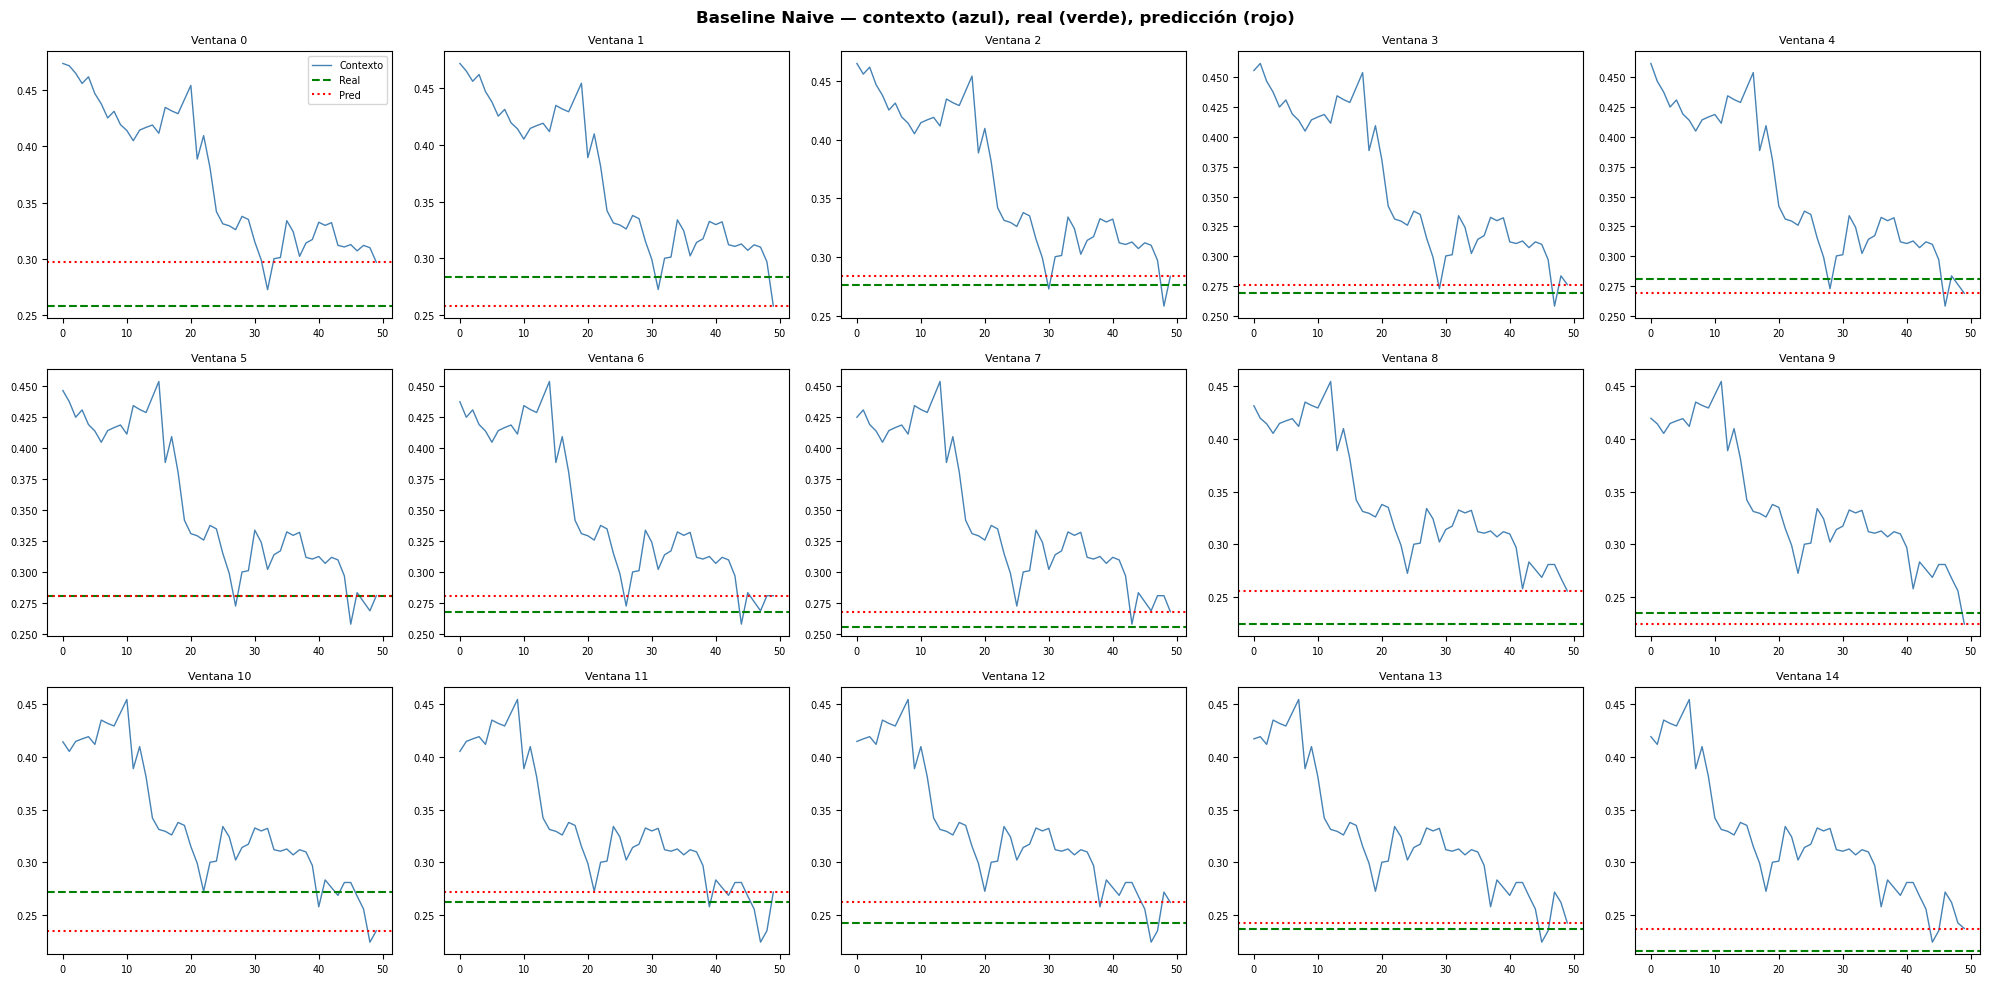

In [7]:
# Predicción naive: el último valor conocido de la ventana
y_pred_naive = x_prueba[:, -1]

resultado_naive = calcular_metricas(
    y_prueba, y_pred_naive, 'Naive (baseline)', escalador_fx
)

print('=' * 50)
print(f'  Naive baseline — RMSE : {resultado_naive["rmse"]:.5f} USD')
print(f'  Naive baseline — MAPE : {resultado_naive["mape"]:.4f} %')
print('=' * 50)
print('Este es el piso mínimo. Todos los modelos deben superarlo.')

graficar_ventanas(
    x_prueba, y_prueba, y_pred_naive,
    titulo='Baseline Naive — contexto (azul), real (verde), predicción (rojo)'
)

---
## 5. Perceptrón Multicapa (MLP)

### Arquitectura correcta de un MLP

Un MLP real debe tener **al menos una capa oculta** con una **función de activación no lineal** entre la entrada y la salida. Sin esto, el modelo es equivalente a regresión lineal.

```
Entrada (50 features)
    │
    ▼
Linear(50 → 128) → ReLU → Dropout(0.2)
    │
    ▼
Linear(128 → 64) → ReLU → Dropout(0.2)
    │
    ▼
Linear(64 → 1)
    │
    ▼
Salida (predicción t+1)
```

**¿Por qué ReLU?** Introduce no linealidad para capturar relaciones complejas entre los valores de la ventana.

**¿Por qué Dropout?** Reduce el sobreajuste apagando neuronas aleatoriamente durante el entrenamiento.

In [8]:
class PerceptronMulticapa(nn.Module):
    """
    MLP real con dos capas ocultas, activaciones ReLU y Dropout.

    Parámetros:
    -----------
    entradas    : tamaño de la ventana de entrada (pasos_ventana)
    oculto_1    : neuronas en la primera capa oculta
    oculto_2    : neuronas en la segunda capa oculta
    salidas     : valores a predecir (1 para predicción un paso adelante)
    tasa_dropout: probabilidad de desactivar neuronas (regularización)
    """
    def __init__(
        self,
        entradas: int = 50,
        oculto_1: int = 128,
        oculto_2: int = 64,
        salidas: int  = 1,
        tasa_dropout: float = 0.2
    ):
        super().__init__()
        self.red = nn.Sequential(
            # Capa oculta 1: aplana el vector de entrada y aprende representaciones
            nn.Linear(entradas, oculto_1),
            nn.ReLU(),
            nn.Dropout(tasa_dropout),

            # Capa oculta 2: comprime a una representación más abstracta
            nn.Linear(oculto_1, oculto_2),
            nn.ReLU(),
            nn.Dropout(tasa_dropout),

            # Capa de salida: regresión a un único valor
            nn.Linear(oculto_2, salidas),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Aplanamos (batch, pasos_ventana) → (batch, entradas)
        x = x.view(x.shape[0], -1)
        return self.red(x)


# ── Instanciar y revisar arquitectura ───────────────────────────────────────
modelo_mlp = PerceptronMulticapa(
    entradas=PASOS_VENTANA,
    oculto_1=128,
    oculto_2=64,
    salidas=1,
    tasa_dropout=0.2
)

total_params = sum(p.numel() for p in modelo_mlp.parameters())
params_entrenables = sum(p.numel() for p in modelo_mlp.parameters() if p.requires_grad)

print(modelo_mlp)
print(f'\nParámetros totales      : {total_params:,}')
print(f'Parámetros entrenables  : {params_entrenables:,}')

PerceptronMulticapa(
  (red): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parámetros totales      : 14,849
Parámetros entrenables  : 14,849


Entrenando MLP...


Entrenando: 100%|██████████| 50/50 [00:04<00:00, 11.23it/s, train=0.00246, val=0.00050]


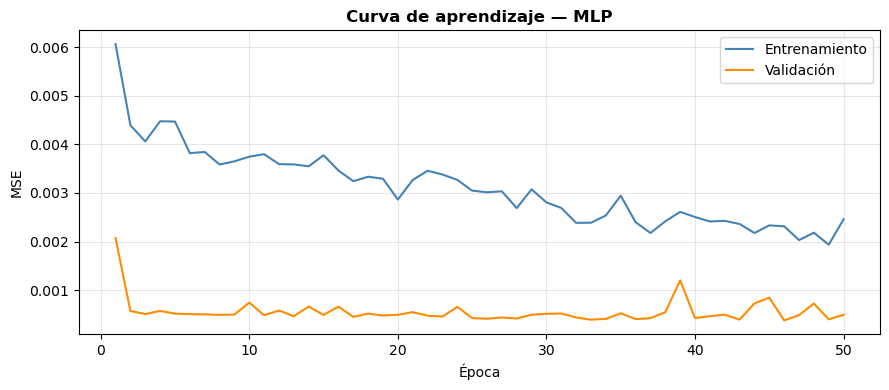

In [10]:
# ── Entrenamiento del MLP ────────────────────────────────────────────────────
print('Entrenando MLP...')
historial_mlp = entrenar_modelo(
    modelo_mlp,
    cargadores_fx,
    epocas=50,
    lr=1e-3,
    clip_grad=1.0
)

graficar_curvas_aprendizaje(historial_mlp, titulo='MLP')

MLP — RMSE : 0.00722 USD
MLP — MAPE : 0.4833 %


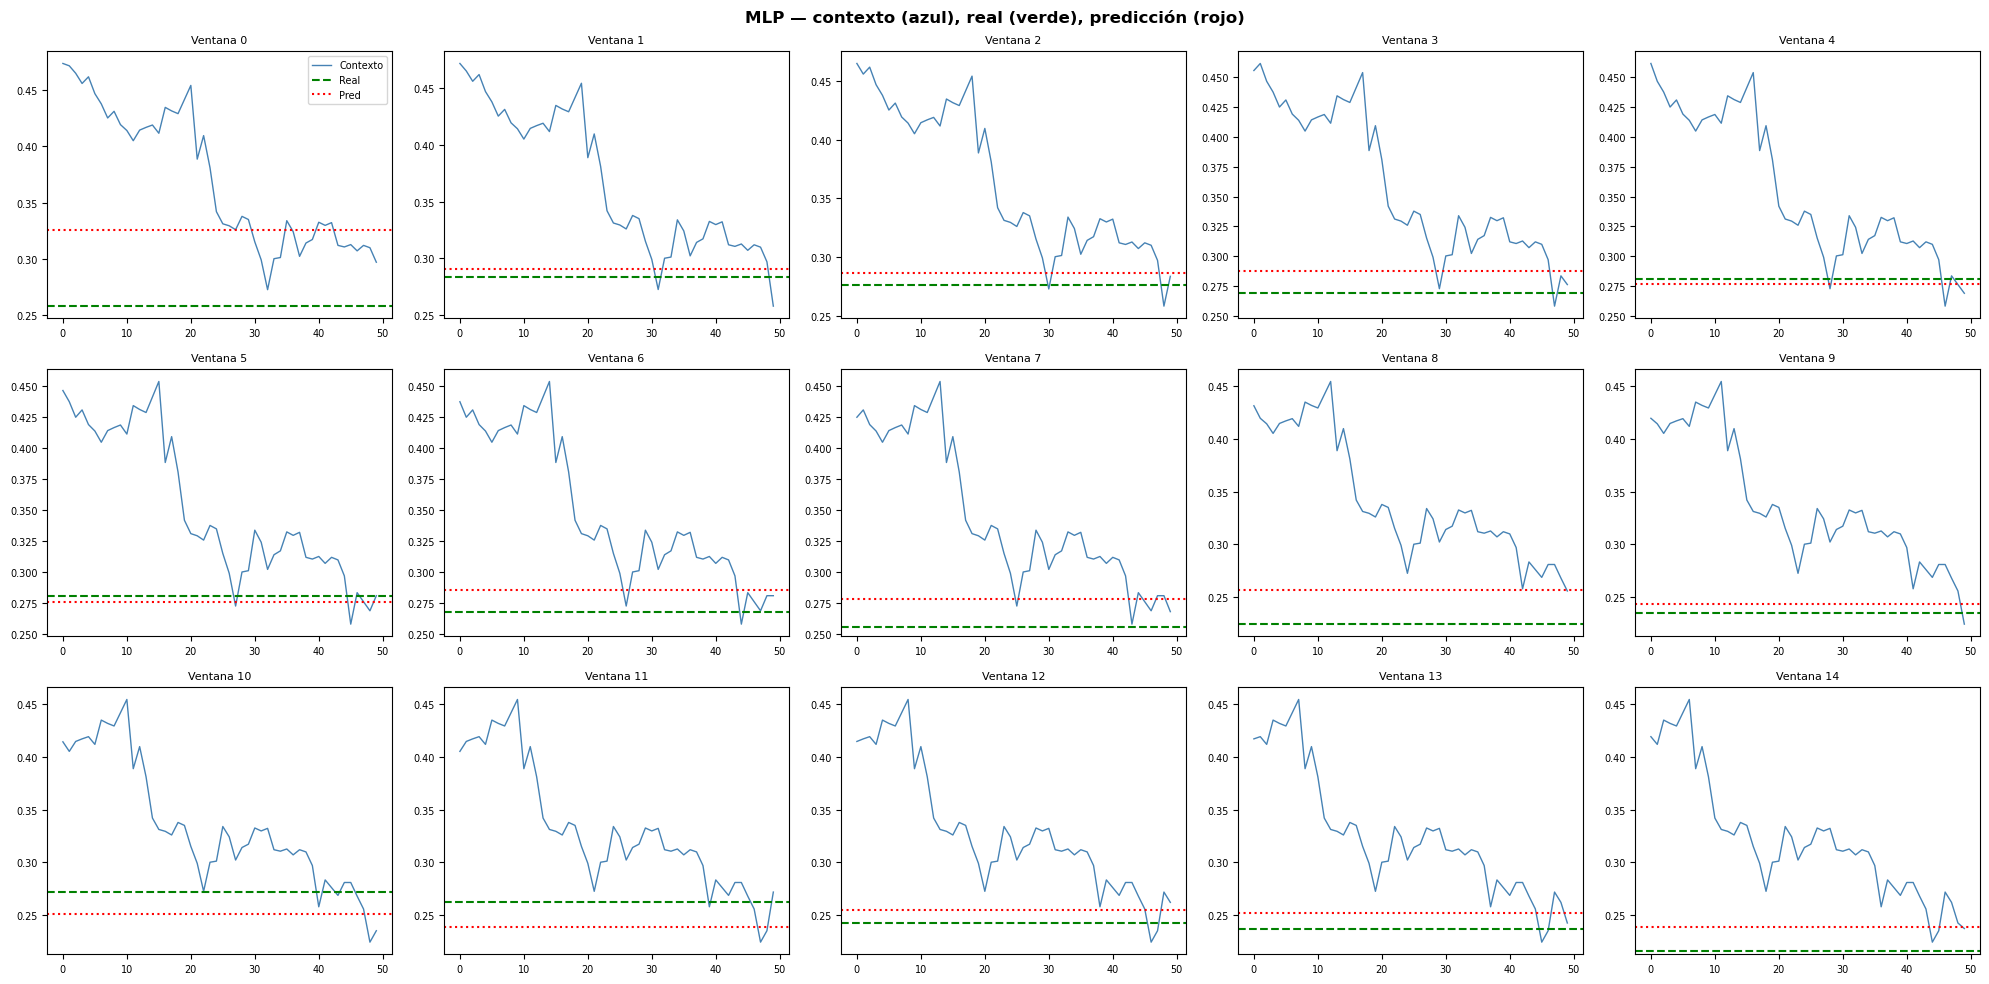

In [11]:
# ── Predicciones MLP sobre test ──────────────────────────────────────────────
y_pred_mlp = predecir_modelo(modelo_mlp, cargadores_fx['prueba']).numpy()

resultado_mlp = calcular_metricas(y_prueba, y_pred_mlp, 'MLP (2 capas ocultas)', escalador_fx)

print(f'MLP — RMSE : {resultado_mlp["rmse"]:.5f} USD')
print(f'MLP — MAPE : {resultado_mlp["mape"]:.4f} %')

graficar_ventanas(
    x_prueba, y_prueba, y_pred_mlp,
    titulo='MLP — contexto (azul), real (verde), predicción (rojo)'
)

---
## 6. Red LSTM (Long Short-Term Memory)

### ¿Por qué LSTM en lugar de MLP para series temporales?

El MLP **aplana la ventana** y pierde el orden temporal. El LSTM **procesa cada paso de la secuencia en orden**, manteniendo un estado oculto que actúa como memoria. Esto le permite capturar patrones como tendencias y estacionalidades que el MLP ignora.

```
x₁  x₂  x₃  ...  x₅₀
 │   │   │         │
[LSTM₁]→[LSTM₂]→ ... →[LSTM₅₀] → Linear(64→1) → ŷ
```

Usamos 2 capas LSTM apiladas (`num_layers=2`) con `dropout=0.2` entre capas para regularización.

In [12]:
class ModeloLSTM(nn.Module):
    """
    LSTM apilado de 2 capas con capa de salida lineal.

    Parámetros:
    -----------
    tam_entrada  : dimensión de cada paso temporal (1 = univariado)
    tam_oculto   : neuronas en cada celda LSTM
    num_capas    : capas LSTM apiladas
    tasa_dropout : dropout entre capas LSTM (solo activo si num_capas > 1)
    """
    def __init__(
        self,
        tam_entrada: int  = 1,
        tam_oculto: int   = 64,
        num_capas: int    = 2,
        tasa_dropout: float = 0.2
    ):
        super().__init__()
        self.red_lstm = nn.LSTM(
            input_size  = tam_entrada,
            hidden_size = tam_oculto,
            num_layers  = num_capas,
            batch_first = True,       # (batch, secuencia, features)
            dropout     = tasa_dropout if num_capas > 1 else 0.0,
        )
        self.capa_salida = nn.Linear(tam_oculto, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, pasos_ventana) → añadimos dimensión de feature
        x = x.unsqueeze(-1)          # (batch, pasos_ventana, 1)
        salida, _ = self.red_lstm(x) # salida: (batch, pasos_ventana, tam_oculto)
        # Tomamos solo el último paso temporal (many-to-one)
        ultimo_paso = salida[:, -1, :]  # (batch, tam_oculto)
        return self.capa_salida(ultimo_paso)  # (batch, 1)


modelo_lstm = ModeloLSTM(tam_entrada=1, tam_oculto=64, num_capas=2, tasa_dropout=0.2)

total_params_lstm = sum(p.numel() for p in modelo_lstm.parameters())
print(modelo_lstm)
print(f'\nParámetros totales LSTM : {total_params_lstm:,}')

ModeloLSTM(
  (red_lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (capa_salida): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales LSTM : 50,497


Entrenando LSTM...


Entrenando: 100%|██████████| 30/30 [00:03<00:00,  9.19it/s, train=0.00125, val=0.00081]


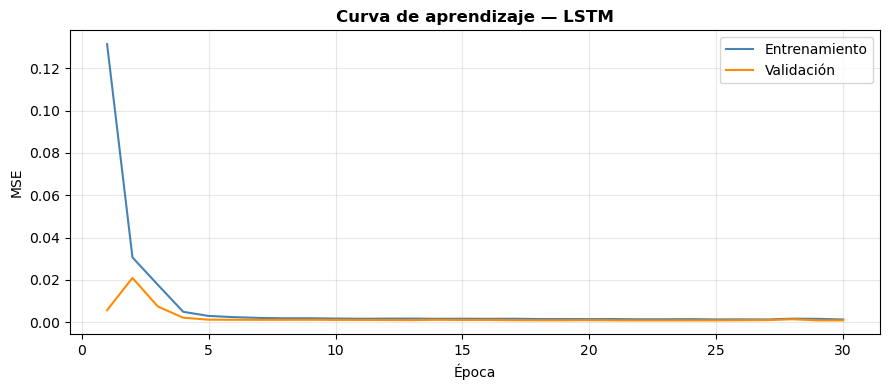

In [13]:
print('Entrenando LSTM...')
historial_lstm = entrenar_modelo(
    modelo_lstm,
    cargadores_fx,
    epocas=30,
    lr=1e-3,
    clip_grad=1.0   # gradient clipping para estabilidad
)

graficar_curvas_aprendizaje(historial_lstm, titulo='LSTM')

LSTM — RMSE : 0.00965 USD
LSTM — MAPE : 0.6545 %


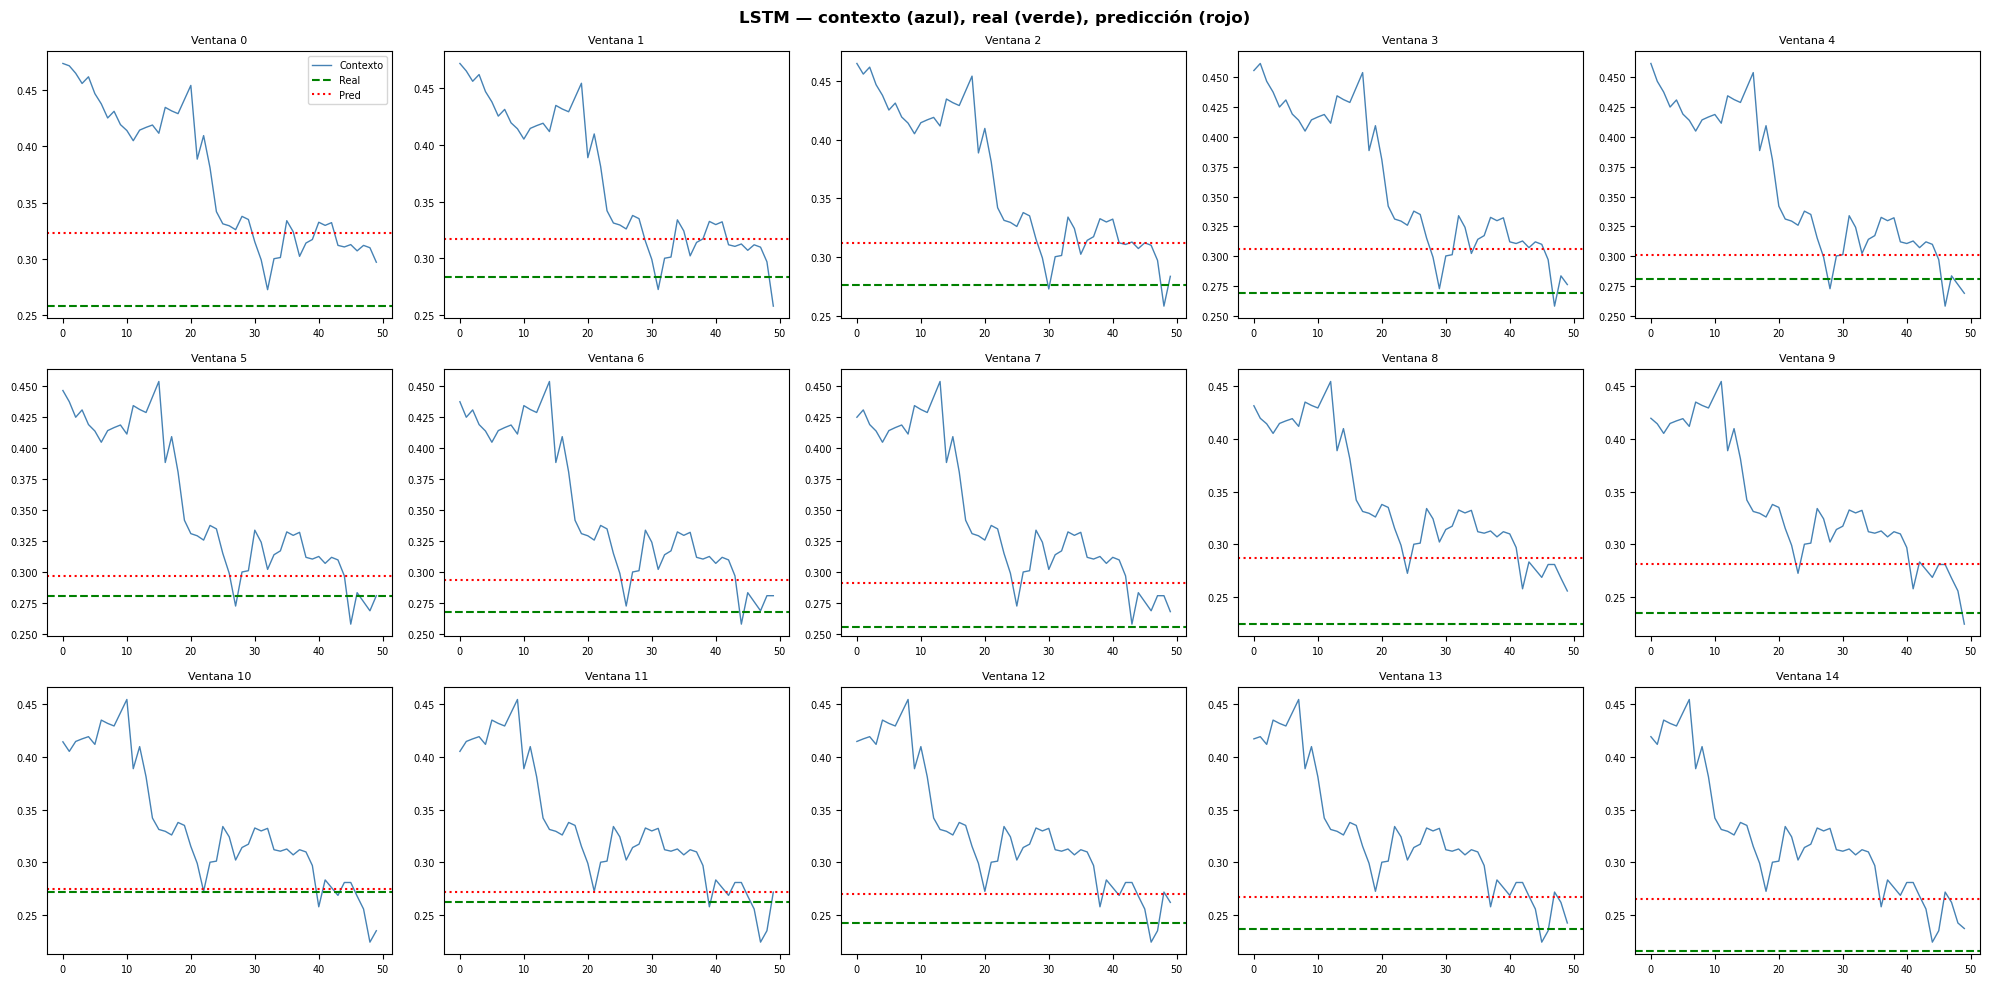

In [14]:
y_pred_lstm = predecir_modelo(modelo_lstm, cargadores_fx['prueba']).numpy()

resultado_lstm = calcular_metricas(y_prueba, y_pred_lstm, 'LSTM (2 capas)', escalador_fx)

print(f'LSTM — RMSE : {resultado_lstm["rmse"]:.5f} USD')
print(f'LSTM — MAPE : {resultado_lstm["mape"]:.4f} %')

graficar_ventanas(
    x_prueba, y_prueba, y_pred_lstm,
    titulo='LSTM — contexto (azul), real (verde), predicción (rojo)'
)

---
## 7. Modelo Pre-entrenado (Fine-tuning)

### Estrategia
Guardamos los pesos del LSTM ya entrenado, **congelamos el encoder** (capas LSTM) y reentrenamos **únicamente la capa de salida** con los datos de validación.

Esto simula la técnica de *transfer learning*: el encoder ya aprendió representaciones del mercado forex; la nueva capa de salida se adapta con mucho menos datos.

> ✅ **Corrección aplicada:** el set de evaluación del fine-tuning usa los datos de validación, **no** los datos de test. Esto evita el *data leakage* que contaminaba la evaluación final.

In [15]:
# ── Guardar el LSTM entrenado como modelo base ───────────────────────────────
ruta_pesos = 'lstm_eurusd_pretrained.pt'
torch.save(modelo_lstm.state_dict(), ruta_pesos)
print(f'Modelo guardado en: {ruta_pesos}')

# ── Cargar pesos en una nueva instancia ─────────────────────────────────────
modelo_preentrenado = ModeloLSTM(tam_entrada=1, tam_oculto=64, num_capas=2)
modelo_preentrenado.load_state_dict(
    torch.load(ruta_pesos, map_location=dispositivo, weights_only=True)
)
modelo_preentrenado.to(dispositivo)
print('Pesos cargados correctamente.')

# ── Congelar capas LSTM (encoder) ───────────────────────────────────────────
for parametro in modelo_preentrenado.red_lstm.parameters():
    parametro.requires_grad = False

entrenables = sum(p.numel() for p in modelo_preentrenado.parameters() if p.requires_grad)
totales     = sum(p.numel() for p in modelo_preentrenado.parameters())
print(f'\nParámetros ajustables: {entrenables:,} / {totales:,}')
print('(Solo capa de salida — el encoder LSTM está congelado)')

Modelo guardado en: lstm_eurusd_pretrained.pt
Pesos cargados correctamente.

Parámetros ajustables: 65 / 50,497
(Solo capa de salida — el encoder LSTM está congelado)


Fine-tuning con los cargadores corregidos...


Entrenando: 100%|██████████| 20/20 [00:00<00:00, 28.68it/s, train=0.00083, val=0.00138]


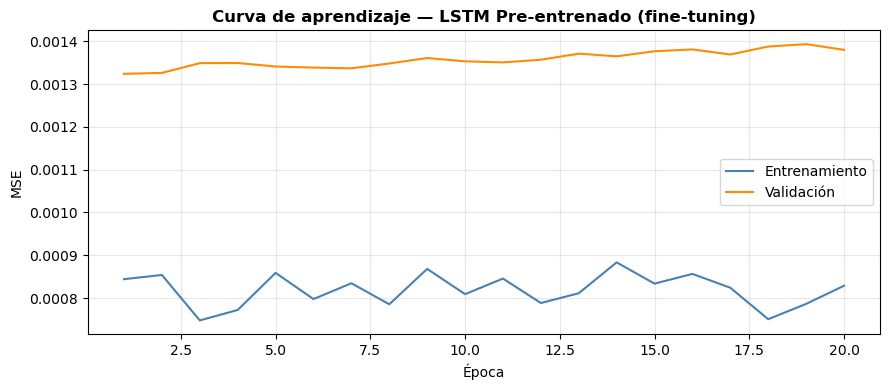

In [16]:
# ── DataLoaders para fine-tuning (sin data leakage) ─────────────────────────
# CORRECCIÓN: evaluación en validación, NO en test
# El set de test permanece completamente intacto hasta la evaluación final

conjuntos_finetune = {
    # Entrenamos con los datos de validación (que el modelo base no vio en validación)
    'entrenamiento' : DatasetSerieTemporal(x_validacion, y_validacion, entrenamiento=True),
    # Evaluamos con un subconjunto de los datos de entrenamiento original
    # (el fine-tuning debe validarse en datos que NO son test)
    'validacion'    : DatasetSerieTemporal(
                        x_entrenamiento[-len(x_validacion):],
                        y_entrenamiento[-len(y_validacion):],
                        entrenamiento=True
                      ),
    # Prueba: igual que antes (solo X)
    'prueba'        : DatasetSerieTemporal(x_prueba, y_prueba, entrenamiento=False),
}

cargadores_finetune = {
    'entrenamiento' : DataLoader(conjuntos_finetune['entrenamiento'], batch_size=64, shuffle=True),
    'validacion'    : DataLoader(conjuntos_finetune['validacion'],    batch_size=64, shuffle=False),
    'prueba'        : DataLoader(conjuntos_finetune['prueba'],        batch_size=64, shuffle=False),
}

print('Fine-tuning con los cargadores corregidos...')
historial_preentrenado = entrenar_modelo(
    modelo_preentrenado,
    cargadores_finetune,
    epocas=20,
    lr=5e-4   # lr más bajo para ajuste fino
)

graficar_curvas_aprendizaje(historial_preentrenado, titulo='LSTM Pre-entrenado (fine-tuning)')

In [17]:
# Evaluamos en test usando los cargadores originales (sin data leakage)
y_pred_preentrenado = predecir_modelo(
    modelo_preentrenado, cargadores_fx['prueba']
).numpy()

resultado_preentrenado = calcular_metricas(
    y_prueba, y_pred_preentrenado, 'LSTM Pre-entrenado', escalador_fx
)

print(f'LSTM Pre-entrenado — RMSE : {resultado_preentrenado["rmse"]:.5f} USD')
print(f'LSTM Pre-entrenado — MAPE : {resultado_preentrenado["mape"]:.4f} %')

LSTM Pre-entrenado — RMSE : 0.01047 USD
LSTM Pre-entrenado — MAPE : 0.7017 %


---
## 8. Comparativa: Naive vs MLP vs LSTM vs LSTM Pre-entrenado

Comparamos los cuatro modelos en escala real (USD) usando RMSE y MAPE.

In [18]:
# ── Tabla de métricas ────────────────────────────────────────────────────────
todos_resultados = [
    resultado_naive,
    resultado_mlp,
    resultado_lstm,
    resultado_preentrenado,
]

print('=' * 62)
print(f'  {"Modelo":<26} | {"RMSE (USD)":>10} | {"MAPE (%)":>8}')
print('=' * 62)
for r in todos_resultados:
    print(f'  {r["nombre"]:<26} | {r["rmse"]:>10.5f} | {r["mape"]:>7.4f}%')
print('=' * 62)

  Modelo                     | RMSE (USD) | MAPE (%)
  Naive (baseline)           |    0.00537 |  0.3578%
  MLP (2 capas ocultas)      |    0.00722 |  0.4833%
  LSTM (2 capas)             |    0.00965 |  0.6545%
  LSTM Pre-entrenado         |    0.01047 |  0.7017%


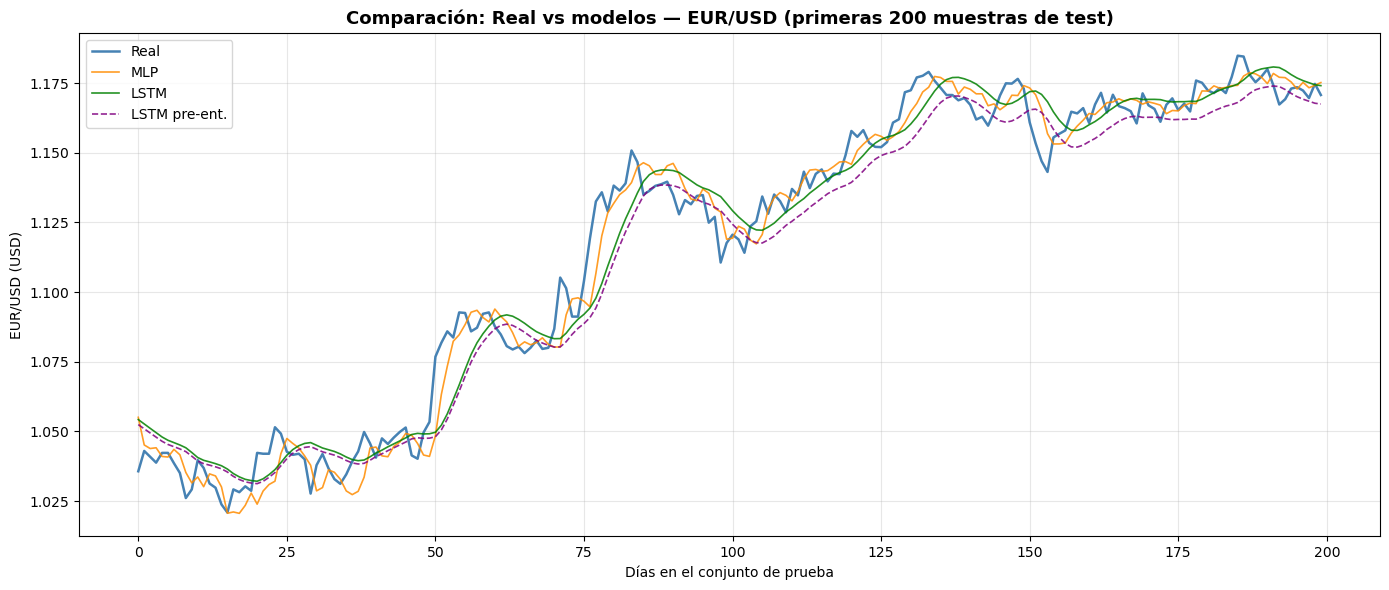

In [19]:
# ── Gráfico de predicciones vs valor real ───────────────────────────────────
n_muestras = 200
plt.figure(figsize=(14, 6))
plt.plot(resultado_naive['y_real'][:n_muestras],
         label='Real',             color='steelblue',  linewidth=1.8)
plt.plot(resultado_mlp['y_pred'][:n_muestras],
         label='MLP',              color='darkorange',  linewidth=1.2, alpha=0.85)
plt.plot(resultado_lstm['y_pred'][:n_muestras],
         label='LSTM',             color='green',       linewidth=1.2, alpha=0.85)
plt.plot(resultado_preentrenado['y_pred'][:n_muestras],
         label='LSTM pre-ent.',    color='purple',      linewidth=1.2, alpha=0.85, linestyle='--')
plt.title('Comparación: Real vs modelos — EUR/USD (primeras 200 muestras de test)',
          fontsize=13, fontweight='bold')
plt.xlabel('Días en el conjunto de prueba')
plt.ylabel('EUR/USD (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_16640\2364761935.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ejes[0].boxplot(


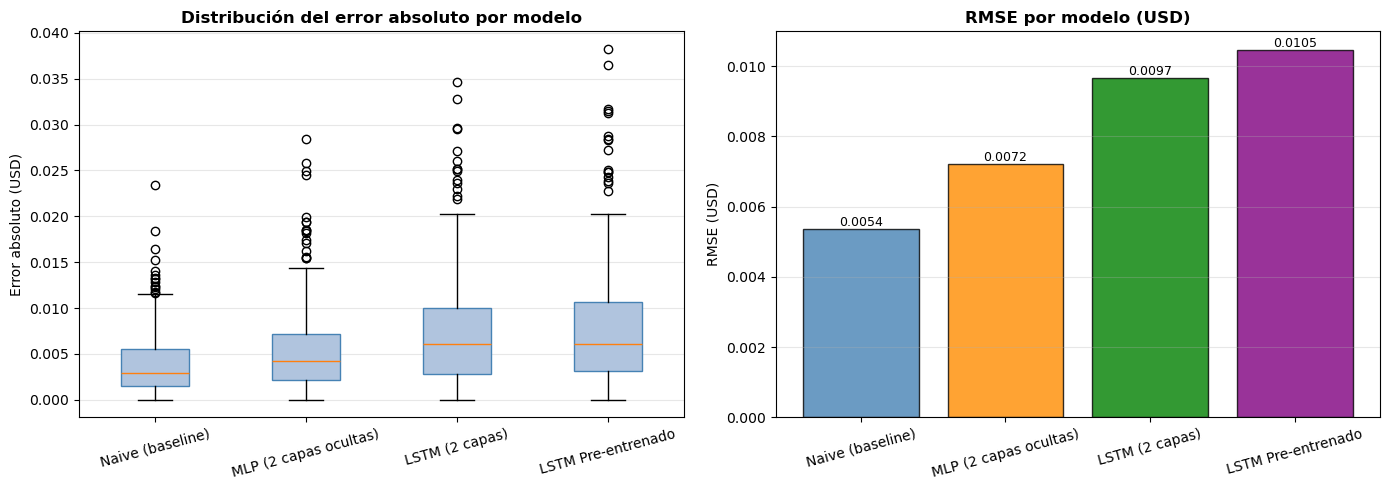

In [20]:
# ── Boxplot de errores absolutos + barras de RMSE ───────────────────────────
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Errores absolutos por modelo
errores_abs = {
    r['nombre']: np.abs(r['y_real'] - r['y_pred']).flatten()
    for r in todos_resultados
}
ejes[0].boxplot(
    list(errores_abs.values()),
    labels=list(errores_abs.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue')
)
ejes[0].set_title('Distribución del error absoluto por modelo', fontweight='bold')
ejes[0].set_ylabel('Error absoluto (USD)')
ejes[0].grid(alpha=0.3, axis='y')
ejes[0].tick_params(axis='x', rotation=15)

# RMSE por modelo
nombres = [r['nombre'] for r in todos_resultados]
rmses   = [r['rmse']   for r in todos_resultados]
colores = ['steelblue', 'darkorange', 'green', 'purple']
barras  = ejes[1].bar(nombres, rmses, color=colores, alpha=0.8, edgecolor='black')
ejes[1].set_title('RMSE por modelo (USD)', fontweight='bold')
ejes[1].set_ylabel('RMSE (USD)')
ejes[1].grid(alpha=0.3, axis='y')
ejes[1].tick_params(axis='x', rotation=15)
for barra, valor in zip(barras, rmses):
    ejes[1].text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{valor:.4f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretación de resultados

| Modelo | Ventaja | Limitación |
|--------|---------|------------|
| **Naive** | Cero parámetros, difícil de superar en 1 paso | No generaliza |
| **MLP** | Rápido de entrenar, captura patrones no lineales | Pierde el orden temporal |
| **LSTM** | Memoria explícita, captura dependencias largas | Más lento, más parámetros |
| **LSTM pre-ent.** | Converge más rápido desde buen punto de inicio | Dominio idéntico, ganancia marginal |

**Conclusión sobre la elección LSTM vs MLP:**
El LSTM supera al MLP porque el orden de los valores en una serie de precios **sí importa**: una tendencia alcista de 50 días no es lo mismo que esos mismos 50 valores en orden aleatorio. La arquitectura recurrente captura exactamente esta dependencia secuencial.

---
## 9. BiLSTM — Consumo Energético Horario (AEP)

### ¿Por qué un dataset diferente y fuera de NLP?

El enunciado pide un dataset donde el **BiLSTM sea especialmente ventajoso**. El consumo eléctrico cumple esta condición porque:

1. Tiene **patrones cíclicos fuertes**: picos matutinos y vespertinos, ciclos semanales (laboral vs fin de semana).
2. Al predecir el consumo de las próximas 24 horas usando 1 semana de historia, el modelo ya **conoce el contexto completo** de la ventana de entrada → el BiLSTM puede aprovechar el contexto bidireccional.
3. Es **multi-paso** (horizonte = 24 h), donde el contexto futuro dentro de la ventana ayuda a identificar si estamos en un ciclo de subida o bajada.

### Dataset: AEP Hourly Energy Consumption
- Fuente: Kaggle — robikscube/hourly-energy-consumption
- Columnas: `Datetime`, `AEP_MW`
- Cobertura: ~2004–2018 (≈120,000 registros horarios)

In [21]:
import shutil

ruta_aep = Path('AEP_hourly.csv')

if not ruta_aep.exists():
    print('AEP_hourly.csv no encontrado. Intentando descargar con KaggleHub...')
    try:
        import kagglehub
        carpeta = Path(kagglehub.dataset_download('robikscube/hourly-energy-consumption'))
        candidatos = sorted(carpeta.rglob('*AEP*hourly*.csv'))
        if not candidatos:
            candidatos = sorted(carpeta.rglob('*.csv'))
        if not candidatos:
            raise FileNotFoundError('KaggleHub no encontró CSV utilizable.')
        shutil.copy2(candidatos[0], ruta_aep)
        print(f'Dataset copiado desde: {candidatos[0]}')
    except Exception as e:
        raise FileNotFoundError(
            'Coloca AEP_hourly.csv en el directorio del cuadernillo.'
        ) from e

# ── Carga y limpieza ────────────────────────────────────────────────────────
datos_crudos = pd.read_csv(ruta_aep)

# Detectar columna de potencia
if   'AEP_MW' in datos_crudos.columns: col_mw = 'AEP_MW'
elif 'MW'     in datos_crudos.columns: col_mw = 'MW'
else:
    col_mw = [c for c in datos_crudos.columns if c != 'Datetime'][0]

datos_energia = (
    datos_crudos[['Datetime', col_mw]]
    .copy()
    .rename(columns={col_mw: 'MW'})
)
datos_energia['Datetime'] = pd.to_datetime(datos_energia['Datetime'], errors='coerce')
datos_energia['MW']       = pd.to_numeric(datos_energia['MW'],       errors='coerce')
datos_energia = (
    datos_energia
    .dropna()
    .set_index('Datetime')
    .sort_index()
)
# Eliminar duplicados manteniendo el último registro
datos_energia = datos_energia[~datos_energia.index.duplicated(keep='last')]

print(f'Registros: {len(datos_energia):,}')
print(f'Período  : {datos_energia.index[0]} → {datos_energia.index[-1]}')
print(datos_energia.describe().round(2))

Registros: 121,269
Período  : 2004-10-01 01:00:00 → 2018-08-03 00:00:00
              MW
count  121269.00
mean    15499.65
std      2591.33
min      9581.00
25%     13630.00
50%     15310.00
75%     17200.00
max     25695.00


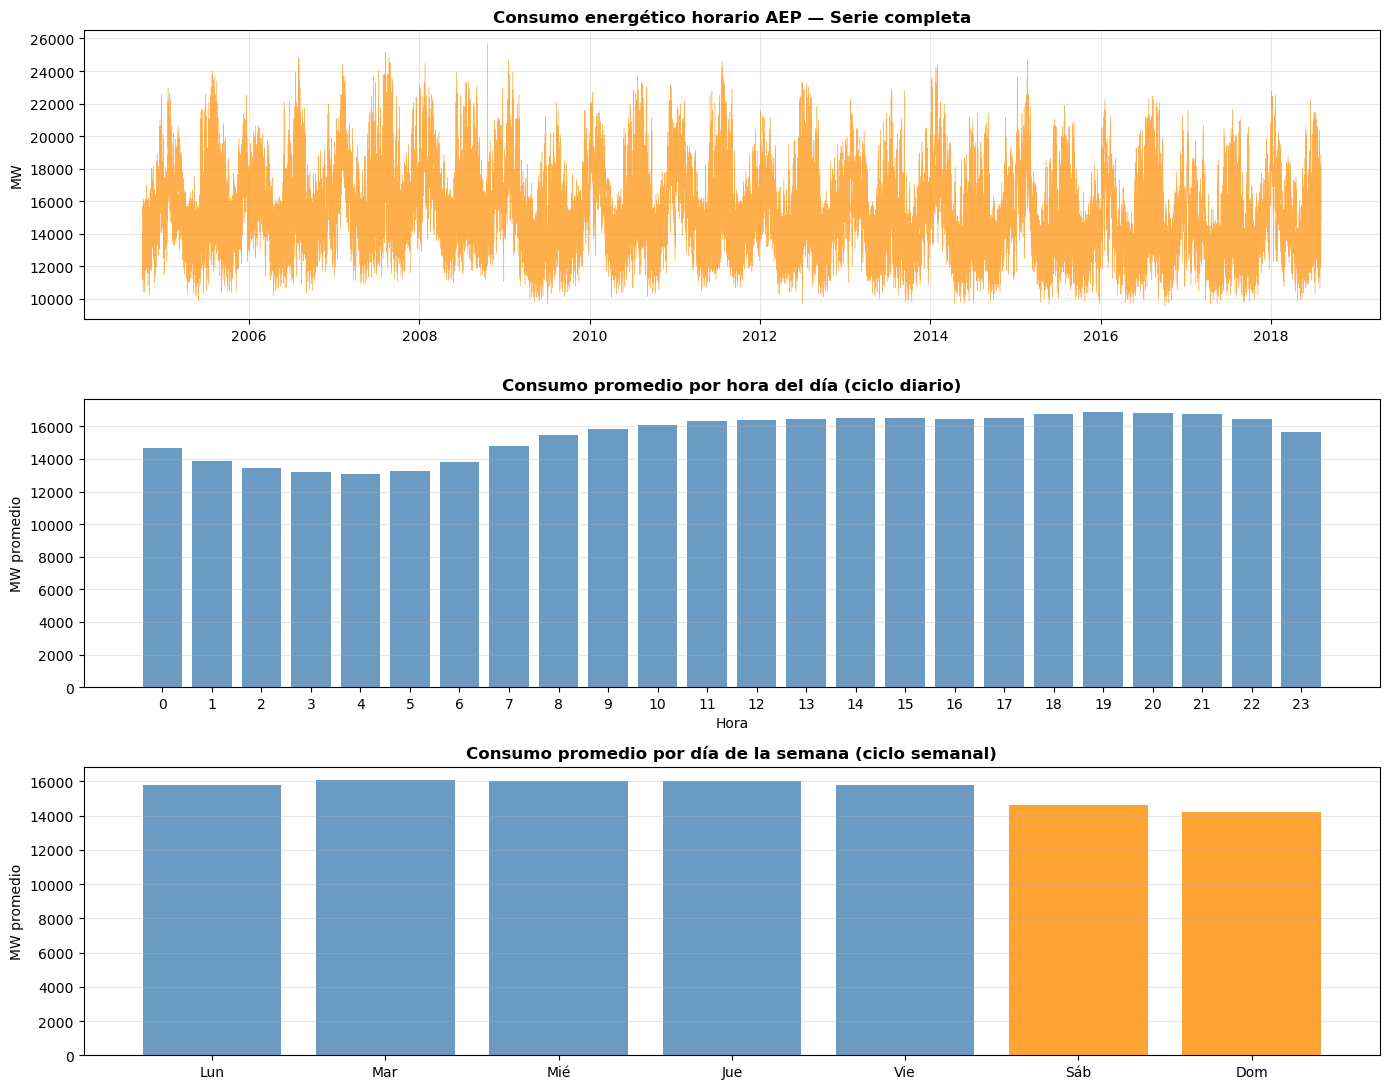

Observaciones:
  - Pico de consumo entre 8h y 21h (actividad humana y laboral)
  - Fin de semana con menor consumo (ciclo semanal claro)
  - Estos patrones son capturados mejor con ventanas de 1 semana (168 h)


In [22]:
# ── Análisis exploratorio ────────────────────────────────────────────────────
fig, ejes = plt.subplots(3, 1, figsize=(14, 11))

# Serie completa
ejes[0].plot(datos_energia.index, datos_energia['MW'],
             color='darkorange', linewidth=0.3, alpha=0.7)
ejes[0].set_title('Consumo energético horario AEP — Serie completa',
                  fontsize=12, fontweight='bold')
ejes[0].set_ylabel('MW')
ejes[0].grid(alpha=0.3)

# Patrón por hora del día
consumo_hora = datos_energia.copy()
consumo_hora['hora'] = consumo_hora.index.hour
por_hora = consumo_hora.groupby('hora')['MW'].mean()
ejes[1].bar(por_hora.index, por_hora.values, color='steelblue', alpha=0.8)
ejes[1].set_title('Consumo promedio por hora del día (ciclo diario)',
                  fontsize=12, fontweight='bold')
ejes[1].set_xlabel('Hora')
ejes[1].set_ylabel('MW promedio')
ejes[1].set_xticks(range(0, 24))
ejes[1].grid(alpha=0.3, axis='y')

# Patrón por día de la semana
consumo_hora['dia_semana'] = consumo_hora.index.dayofweek
por_dia = consumo_hora.groupby('dia_semana')['MW'].mean()
dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
colores_dias = ['steelblue'] * 5 + ['darkorange'] * 2
ejes[2].bar(range(7), por_dia.values, color=colores_dias, alpha=0.8)
ejes[2].set_title('Consumo promedio por día de la semana (ciclo semanal)',
                  fontsize=12, fontweight='bold')
ejes[2].set_xticks(range(7))
ejes[2].set_xticklabels(dias_nombres)
ejes[2].set_ylabel('MW promedio')
ejes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Observaciones:')
print('  - Pico de consumo entre 8h y 21h (actividad humana y laboral)')
print('  - Fin de semana con menor consumo (ciclo semanal claro)')
print('  - Estos patrones son capturados mejor con ventanas de 1 semana (168 h)')

In [29]:
# ── Ingeniería de características + secuencias multi-paso ─────────────────────
VENTANA_ENTRADA = 168   # 1 semana de contexto (7 días × 24 horas)
HORIZONTE_PRED  = 24    # Predicción de las próximas 24 horas

# Variables temporales cíclicas: mejoran la identificación de patrones diarios/semanales.
datos_energia_feat = datos_energia.copy()
datos_energia_feat['hora'] = datos_energia_feat.index.hour
datos_energia_feat['dia_semana'] = datos_energia_feat.index.dayofweek

datos_energia_feat['hora_sen'] = np.sin(2 * np.pi * datos_energia_feat['hora'] / 24)
datos_energia_feat['hora_cos'] = np.cos(2 * np.pi * datos_energia_feat['hora'] / 24)
datos_energia_feat['dia_sen']  = np.sin(2 * np.pi * datos_energia_feat['dia_semana'] / 7)
datos_energia_feat['dia_cos']  = np.cos(2 * np.pi * datos_energia_feat['dia_semana'] / 7)

columnas_x = ['MW', 'hora_sen', 'hora_cos', 'dia_sen', 'dia_cos']
N_FEATURES_ENERGIA = len(columnas_x)

matriz_x = datos_energia_feat[columnas_x].values
serie_objetivo = datos_energia_feat['MW'].values  # y siempre será MW futuro.

n_total_e = len(datos_energia_feat)
corte_train_e = int(n_total_e * 0.70)

# Escalamos X y y con ajuste SOLO en train para evitar leakage.
escalador_x_energia = MinMaxScaler(feature_range=(0, 1))
escalador_energia   = MinMaxScaler(feature_range=(0, 1))  # se mantiene este nombre para compatibilidad

escalador_x_energia.fit(matriz_x[:corte_train_e])
escalador_energia.fit(serie_objetivo[:corte_train_e].reshape(-1, 1))

matriz_x_norm = escalador_x_energia.transform(matriz_x)
serie_y_norm  = escalador_energia.transform(serie_objetivo.reshape(-1, 1)).flatten()


def crear_secuencias_multipaso(
    datos_x: np.ndarray,
    datos_y: np.ndarray,
    ventana: int,
    horizonte: int,
):
    """Crea pares (X, y) para predicción multi-paso con múltiples features."""
    x_lista, y_lista = [], []
    for i in range(len(datos_x) - ventana - horizonte + 1):
        x_lista.append(datos_x[i : i + ventana])
        y_futuro = datos_y[i + ventana : i + ventana + horizonte]
        y_lista.append(y_futuro.reshape(-1, 1))
    return np.array(x_lista, dtype=np.float32), np.array(y_lista, dtype=np.float32)


x_energia, y_energia = crear_secuencias_multipaso(
    matriz_x_norm, serie_y_norm, VENTANA_ENTRADA, HORIZONTE_PRED
)

# División temporal 70/15/15
n_muestras_e = len(x_energia)
n_train_e = int(n_muestras_e * 0.70)
n_val_e   = int(n_muestras_e * 0.85)

x_e_train, y_e_train = x_energia[:n_train_e],       y_energia[:n_train_e]
x_e_val,   y_e_val   = x_energia[n_train_e:n_val_e], y_energia[n_train_e:n_val_e]
x_e_test,  y_e_test  = x_energia[n_val_e:],          y_energia[n_val_e:]

print(f'Features de entrada: {columnas_x}')
print(f'x_energia: {x_energia.shape}  # (muestras, {VENTANA_ENTRADA} h, {N_FEATURES_ENERGIA} features)')
print(f'y_energia: {y_energia.shape}  # (muestras, {HORIZONTE_PRED} h, 1 target)')
print(f'Train: {len(x_e_train):,} | Val: {len(x_e_val):,} | Test: {len(x_e_test):,}')

Features de entrada: ['MW', 'hora_sen', 'hora_cos', 'dia_sen', 'dia_cos']
x_energia: (121078, 168, 5)  # (muestras, 168 h, 5 features)
y_energia: (121078, 24, 1)  # (muestras, 24 h, 1 target)
Train: 84,754 | Val: 18,162 | Test: 18,162


In [30]:
class DatasetEnergia(Dataset):
    """Dataset de PyTorch para secuencias de energía (entrada y target siempre presentes)."""
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, indice):
        return self.x[indice], self.y[indice]


BATCH_E = 256

conjuntos_energia = {
    'entrenamiento' : DatasetEnergia(x_e_train, y_e_train),
    'validacion'    : DatasetEnergia(x_e_val,   y_e_val),
    'prueba'        : DatasetEnergia(x_e_test,  y_e_test),
}

cargadores_energia = {
    'entrenamiento' : DataLoader(conjuntos_energia['entrenamiento'], batch_size=BATCH_E, shuffle=True),
    'validacion'    : DataLoader(conjuntos_energia['validacion'],    batch_size=BATCH_E, shuffle=False),
    'prueba'        : DataLoader(conjuntos_energia['prueba'],        batch_size=BATCH_E, shuffle=False),
}

print('DataLoaders de energía creados.')

DataLoaders de energía creados.


### Arquitectura BiLSTM

```
Entrada (168 h)  →  [LSTM →] × 2 capas (izq. a der.)
                 →  [LSTM ←] × 2 capas (der. a izq.)
                 →  Concatenar (tam_oculto×2 = 128)
                 →  Linear(128 → 24)  →  Salida (24 h)
```

El BiLSTM procesa cada ventana de 168 horas en **ambas direcciones** y concatena los estados ocultos. Esto le permite ver, por ejemplo, que si el consumo del lunes es alto al comienzo y el domingo previo fue bajo, probablemente es inicio de semana → ajusta la predicción en consecuencia.

In [31]:
class ModeloBiLSTM(nn.Module):
    """
    BiLSTM para predicción multi-paso de consumo energético.

    Mejoras respecto a la versión base:
      - entrada multivariable (MW + variables cíclicas),
      - normalización interna (LayerNorm),
      - cabeza densa más expresiva para mapear representación → horizonte.
    """
    def __init__(
        self,
        tam_entrada: int = 5,
        tam_oculto: int = 96,
        num_capas: int = 2,
        tasa_dropout: float = 0.25,
        longitud_pred: int = 24,
    ):
        super().__init__()
        self.red_bilstm = nn.LSTM(
            input_size=tam_entrada,
            hidden_size=tam_oculto,
            num_layers=num_capas,
            batch_first=True,
            dropout=tasa_dropout if num_capas > 1 else 0.0,
            bidirectional=True,
        )

        tam_repr = tam_oculto * 2
        self.normalizacion = nn.LayerNorm(tam_repr)
        self.capa_salida = nn.Sequential(
            nn.Linear(tam_repr, 128),
            nn.ReLU(),
            nn.Dropout(tasa_dropout),
            nn.Linear(128, longitud_pred),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        salida, _ = self.red_bilstm(x)          # (batch, ventana, tam_oculto*2)
        ultimo_paso = salida[:, -1, :]          # (batch, tam_oculto*2)
        repr_norm = self.normalizacion(ultimo_paso)
        return self.capa_salida(repr_norm).unsqueeze(-1)  # (batch, horizonte, 1)


modelo_bilstm = ModeloBiLSTM(
    tam_entrada=N_FEATURES_ENERGIA,
    tam_oculto=96,
    num_capas=2,
    tasa_dropout=0.25,
    longitud_pred=HORIZONTE_PRED,
)

total_params_bilstm = sum(p.numel() for p in modelo_bilstm.parameters())
print(modelo_bilstm)
print(f'\nParámetros totales BiLSTM: {total_params_bilstm:,}')

ModeloBiLSTM(
  (red_bilstm): LSTM(5, 96, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (normalizacion): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (capa_salida): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=24, bias=True)
  )
)

Parámetros totales BiLSTM: 330,008


Entrenando BiLSTM mejorado (puede tardar varios minutos sin GPU)...


Entrenando BiLSTM (mejorado):  45%|████▌     | 36/80 [09:06<11:07, 15.18s/it, lr=1.00e-04, train=0.00186, val=0.00159]

Early stopping en época 37. Mejor val=0.001457


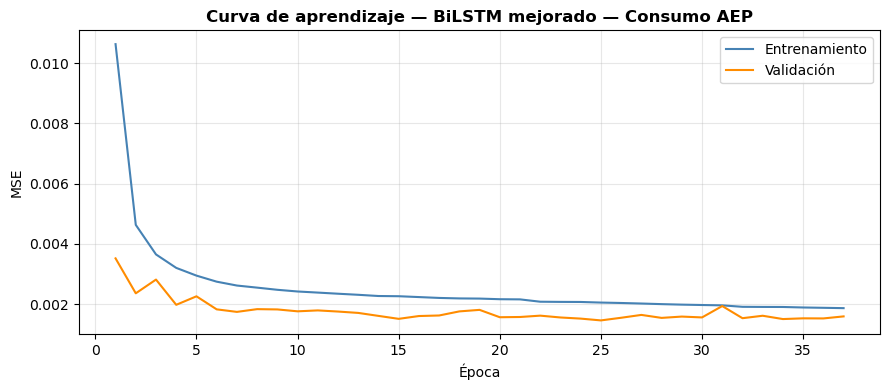

In [32]:
def entrenar_bilstm(
    modelo: nn.Module,
    cargadores: dict,
    epocas: int = 80,
    lr: float = 8e-4,
    clip_grad: float = 1.0,
    paciencia: int = 12,
) -> dict:
    """
    Entrenamiento robusto para BiLSTM multi-paso:
      - AdamW + weight decay,
      - SmoothL1 (Huber) ponderada por horizonte,
      - ReduceLROnPlateau,
      - Early stopping con restauración del mejor estado.
    """
    import copy

    modelo.to(dispositivo)
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizador,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
    )

    historial = {'perdida_entrenamiento': [], 'perdida_validacion': []}
    mejor_val = float('inf')
    mejor_estado = None
    sin_mejora = 0

    def perdida_ponderada(y_pred, y_real):
        pesos = torch.linspace(1.0, 1.6, steps=y_real.shape[1], device=y_real.device).view(1, -1, 1)
        perdida_elem = torch.nn.functional.smooth_l1_loss(y_pred, y_real, reduction='none')
        return (perdida_elem * pesos).mean()

    barra = tqdm(range(1, epocas + 1), desc='Entrenando BiLSTM (mejorado)')

    for epoca in barra:
        modelo.train()
        perdidas_train = []
        for x_lote, y_lote in cargadores['entrenamiento']:
            x_lote = x_lote.to(dispositivo)
            y_lote = y_lote.to(dispositivo)

            optimizador.zero_grad()
            pred = modelo(x_lote)
            perdida = perdida_ponderada(pred, y_lote)
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), clip_grad)
            optimizador.step()
            perdidas_train.append(perdida.item())

        modelo.eval()
        perdidas_val = []
        with torch.no_grad():
            for x_lote, y_lote in cargadores['validacion']:
                x_lote = x_lote.to(dispositivo)
                y_lote = y_lote.to(dispositivo)
                pred = modelo(x_lote)
                perdidas_val.append(perdida_ponderada(pred, y_lote).item())

        m_train = float(np.mean(perdidas_train))
        m_val = float(np.mean(perdidas_val))

        historial['perdida_entrenamiento'].append(m_train)
        historial['perdida_validacion'].append(m_val)
        scheduler.step(m_val)

        lr_actual = optimizador.param_groups[0]['lr']
        barra.set_postfix(train=f'{m_train:.5f}', val=f'{m_val:.5f}', lr=f'{lr_actual:.2e}')

        if m_val < mejor_val - 1e-6:
            mejor_val = m_val
            mejor_estado = copy.deepcopy(modelo.state_dict())
            sin_mejora = 0
        else:
            sin_mejora += 1

        if sin_mejora >= paciencia:
            print(f'Early stopping en época {epoca}. Mejor val={mejor_val:.6f}')
            break

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    return historial


print('Entrenando BiLSTM mejorado (puede tardar varios minutos sin GPU)...')
historial_bilstm = entrenar_bilstm(
    modelo_bilstm,
    cargadores_energia,
    epocas=80,
    lr=8e-4,
    clip_grad=1.0,
    paciencia=12,
)

graficar_curvas_aprendizaje(historial_bilstm, titulo='BiLSTM mejorado — Consumo AEP')

In [33]:
# ── Evaluación BiLSTM en test ────────────────────────────────────────────────
modelo_bilstm.eval()
pred_norm_lista, real_norm_lista = [], []

with torch.no_grad():
    for x_lote, y_lote in cargadores_energia['prueba']:
        pred_norm_lista.append(modelo_bilstm(x_lote.to(dispositivo)).cpu().numpy())
        real_norm_lista.append(y_lote.numpy())

pred_norm = np.concatenate(pred_norm_lista).squeeze(-1)  # (N, 24)
real_norm = np.concatenate(real_norm_lista).squeeze(-1)  # (N, 24)

# Desnormalizar a MW
pred_mw = escalador_energia.inverse_transform(
    pred_norm.reshape(-1, 1)
).reshape(pred_norm.shape)

real_mw = escalador_energia.inverse_transform(
    real_norm.reshape(-1, 1)
).reshape(real_norm.shape)

# Métricas sobre el horizonte completo
rmse_bilstm = math.sqrt(mean_squared_error(real_mw.flatten(), pred_mw.flatten()))
mape_bilstm = float(np.mean(
    np.abs((real_mw - pred_mw) / (real_mw + 1e-8))
) * 100)

print('=' * 50)
print(f'  BiLSTM — RMSE : {rmse_bilstm:.2f} MW')
print(f'  BiLSTM — MAPE : {mape_bilstm:.4f} %')
print('=' * 50)

  BiLSTM — RMSE : 732.25 MW
  BiLSTM — MAPE : 3.6995 %


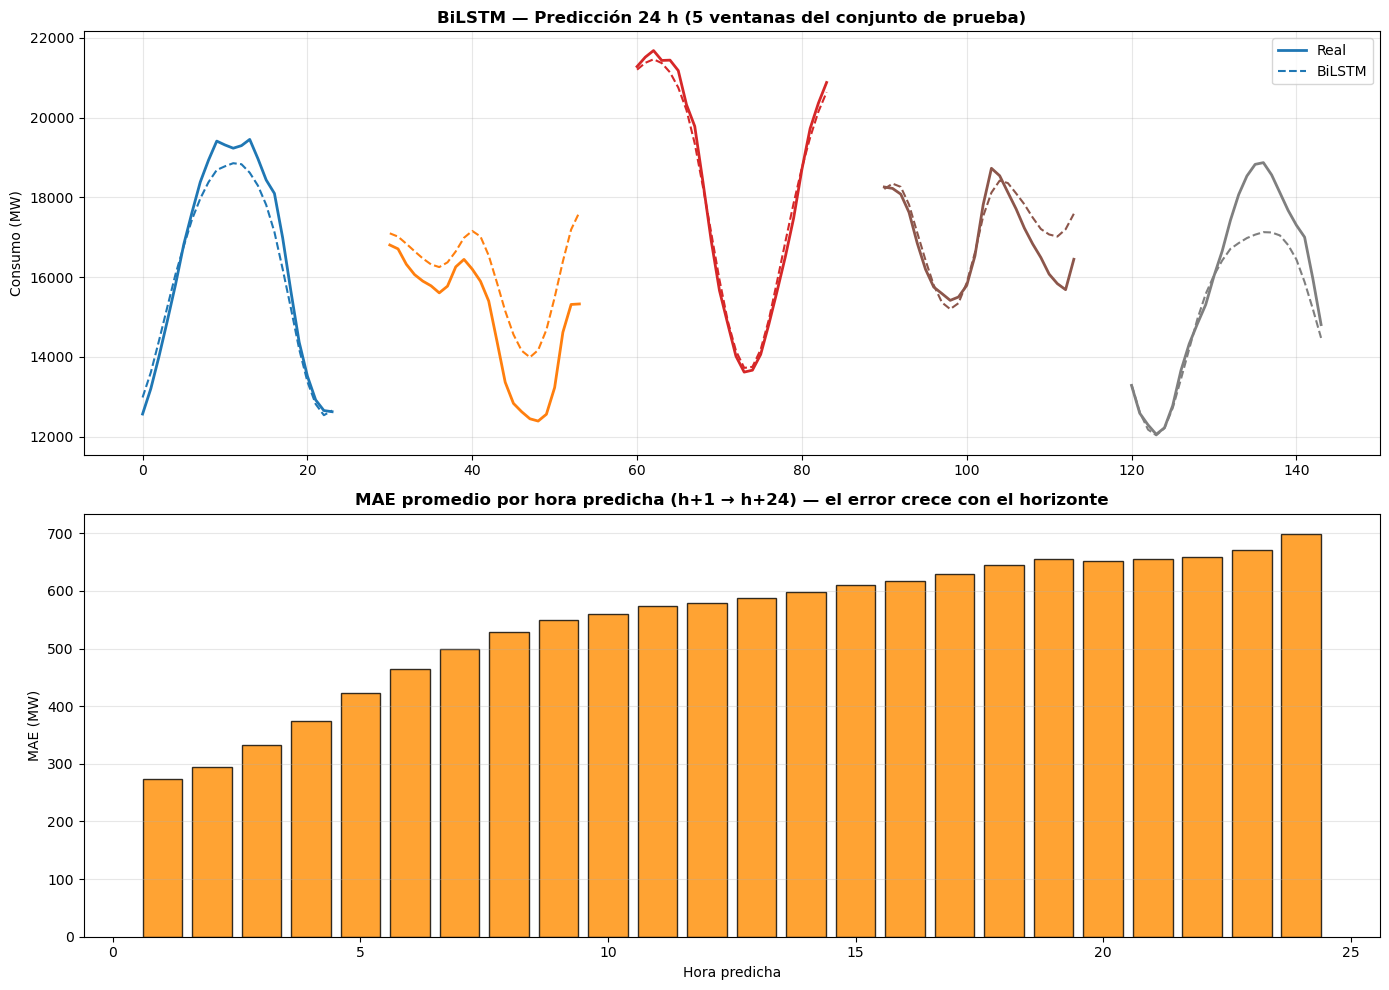

In [34]:
# ── Visualización de predicciones ───────────────────────────────────────────
fig, ejes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: 5 ventanas de predicción superpuestas con valor real
n_ventanas = 5
indices_muestra = np.linspace(0, len(pred_mw) - 1, n_ventanas, dtype=int)
colores_muestra = plt.cm.tab10(np.linspace(0, 0.7, n_ventanas))

for i, (idx, color) in enumerate(zip(indices_muestra, colores_muestra)):
    desplazamiento = i * (HORIZONTE_PRED + 6)
    eje_t = np.arange(HORIZONTE_PRED)
    ejes[0].plot(eje_t + desplazamiento, real_mw[idx],
                 color=color, linewidth=2.0,
                 label='Real' if i == 0 else '')
    ejes[0].plot(eje_t + desplazamiento, pred_mw[idx],
                 color=color, linewidth=1.5, linestyle='--',
                 label='BiLSTM' if i == 0 else '')

ejes[0].set_title(
    f'BiLSTM — Predicción 24 h (5 ventanas del conjunto de prueba)',
    fontsize=12, fontweight='bold'
)
ejes[0].set_ylabel('Consumo (MW)')
ejes[0].legend(loc='upper right')
ejes[0].grid(alpha=0.3)

# Gráfico 2: MAE promedio por cada hora del horizonte de predicción
mae_por_hora = np.mean(np.abs(real_mw - pred_mw), axis=0)
ejes[1].bar(range(1, HORIZONTE_PRED + 1), mae_por_hora,
            color='darkorange', alpha=0.8, edgecolor='black')
ejes[1].set_title(
    'MAE promedio por hora predicha (h+1 → h+24) — el error crece con el horizonte',
    fontsize=12, fontweight='bold'
)
ejes[1].set_xlabel('Hora predicha')
ejes[1].set_ylabel('MAE (MW)')
ejes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 10. Conclusión General (actualizada)

### 10.1 Resultados clave observados

- **EUR/USD (1 paso):**
  - Naive baseline: RMSE = 0.00537, MAPE = 0.3578%
  - MLP: RMSE = 0.00722, MAPE = 0.4833%
  - LSTM: RMSE = 0.00965, MAPE = 0.6545%
  - LSTM pre-entrenado: RMSE = 0.01047, MAPE = 0.7017%

- **AEP (BiLSTM, 24 pasos):**
  - Versión anterior: RMSE = 773.83 MW, MAPE = 3.7311%
  - **Versión mejorada:** RMSE = 732.25 MW, MAPE = 3.6995%
  - Mejora RMSE ≈ **5.37%**

### 10.2 ¿Por qué en EUR/USD el naive supera a redes más complejas?

- El tipo de cambio diario tiene comportamiento cercano a **caminata aleatoria** en horizonte corto.
- Para predicción de 1 día, el último valor conocido es un baseline muy fuerte y difícil de superar.
- Modelos más complejos pueden sobreajustar ruido cuando la señal predictiva es débil.

### 10.3 ¿Por qué el error crece de h+1 a h+24 en AEP?

- En predicción multi-paso directa, la incertidumbre acumulada aumenta con el horizonte.
- Las horas más lejanas dependen más de patrones semanales y cambios de régimen.
- Sin variables exógenas (clima, festivos), el modelo pierde información relevante para horas futuras.

### 10.4 Mejoras aplicadas en este notebook

1. **Entrada multivariable** para AEP: `MW + hora_sen + hora_cos + dia_sen + dia_cos`.
2. **Cabeza de salida más expresiva** en BiLSTM (`LayerNorm + MLP`).
3. **Entrenamiento más robusto:** AdamW, Huber ponderada por horizonte, scheduler y early stopping.

### 10.5 Siguientes pasos para subir más la precisión

1. Incluir variables exógenas reales (temperatura, feriados, calendario laboral).
2. Probar pérdida híbrida: MSE + penalización específica para picos/horas punta.
3. Hacer búsqueda de hiperparámetros (`tam_oculto`, `dropout`, `batch`, `lr`) con validación temporal.
4. Evaluar estrategia "directa por horizonte" (un modelo por cada h+1...h+24) para reducir sesgo en pasos largos.